## Notebook for reading in baseline files, computing the 75th percentile temps, saving it out

In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt
import dask
import dask.array as da
import xarray as xr
from dask.diagnostics import ProgressBar
from dask.utils import format_bytes

In [8]:
#import sys
#!conda install --yes --prefix {sys.prefix} dask

In [6]:
file_path = '../../../Data/ERA5-global/Baseline/*/*.nc'

# open without dask chunking and see if it crashes
#ds = xr.open_mfdataset(file_path) #, chunks={'time': 10})

# chunking but will likely have to load it all for quantile calc
ds = xr.open_mfdataset(file_path)#, chunks={'latitude': 10, 'longitude': 10})

In [7]:
ds.nbytes

45504087672

In [8]:
ds

<xarray.Dataset> Size: 46GB
Dimensions:      (time: 10957, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 88kB 1961-01-01 1961-01-02 ... 1990-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 46GB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-25T22:09 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [9]:
np.unique(ds.time.dt.year.values)

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990])

In [10]:
# load it into memory because I can't do quantile on on the dask dataset (also can't figure out how to do percentile)
ds.load()

<xarray.Dataset> Size: 46GB
Dimensions:      (time: 10957, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 88kB 1961-01-01 1961-01-02 ... 1990-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    t2m          (time, lat, lon) float32 46GB 243.9 243.9 243.9 ... 254.4 254.4
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-25T22:09 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [11]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
c_75 = ds.t2m.quantile(0.75, dim=('time'))
c_75.attrs["long_name"] = "75th percentile 2m Temperature for the data across available time dimension"
c_75.attrs["units"] = "K"
c_75

CPU times: user 2min 24s, sys: 26.4 s, total: 2min 51s
Wall time: 5min 30s


<xarray.DataArray 't2m' (lat: 721, lon: 1440)> Size: 8MB
array([[236.4370575 , 236.4370575 , 236.4370575 , ..., 236.4370575 ,
        236.4370575 , 236.4370575 ],
       [236.18743896, 236.1893158 , 236.19142151, ..., 236.18388367,
        236.18530273, 236.18659973],
       [235.91021729, 235.9200592 , 235.92704773, ..., 235.88049316,
        235.8903656 , 235.90020752],
       ...,
       [270.7281189 , 270.72640991, 270.72720337, ..., 270.73239136,
        270.73184204, 270.73007202],
       [270.74356079, 270.74273682, 270.74200439, ..., 270.74594116,
        270.74508667, 270.74420166],
       [270.7550354 , 270.7550354 , 270.7550354 , ..., 270.7550354 ,
        270.7550354 , 270.7550354 ]])
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B 0.75
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

### assuming everything looks good, then the next cell writes it out

In [12]:
#'../../../Data/ERA5-global/Baseline/*/*.nc'
c_75.to_netcdf("../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc")

### and hopfully this closes the objects to free up memory

In [13]:
ds.close()
c_75.close()

In [14]:
! ls -l "../../../Data/ERA5-global/Baseline/"

total 48840
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:20 1961
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:19 1962
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:19 1963
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:18 1964
drwxr-xr-x@ 14 tedscott  staff      448 Jun 19 13:01 1965
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:18 1966
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:18 1967
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:17 1968
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:17 1969
drwxr-xr-x@ 14 tedscott  staff      448 Jun 24 14:52 1970
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:17 1971
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:16 1972
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:16 1973
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:16 1974
drwxr-xr-x@ 14 tedscott  staff      448 Jun 19 13:01 1975
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:15 1976
drwxr-xr-x@ 14 tedscott  staff      448 Jun 26 10:15 1977
dr

Text(0.5, 1.0, '75th Percentile T2m from 1961 - 1990')

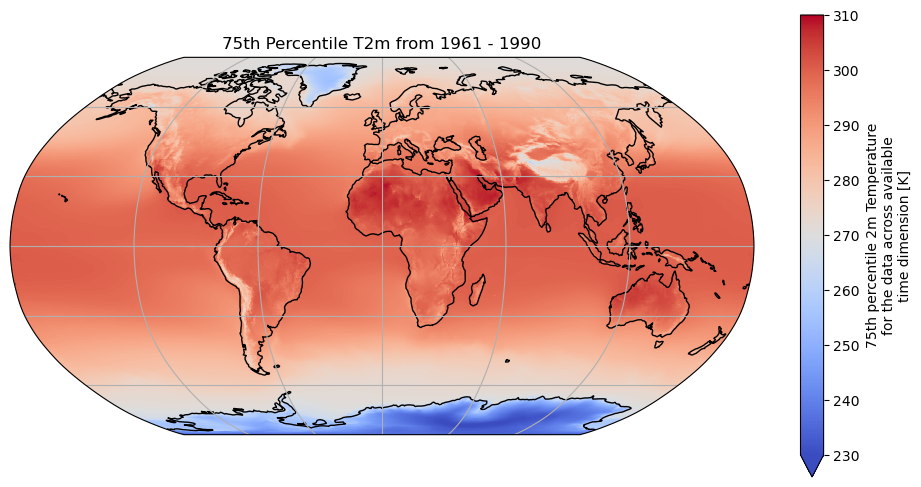

In [15]:
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

# plot first index of SSTs
c_75.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=230,
    vmax=310, # define temp range for colorbar 230 to 310 K
    cmap="coolwarm"
)

plt.title("75th Percentile T2m from 1961 - 1990")

<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_45094/3234872878.py:20: SyntaxWarning: invalid escape sequence '\c'
  fig.colorbar(dataplot, orientation="vertical", label="Temperature ($^\circ C$)",


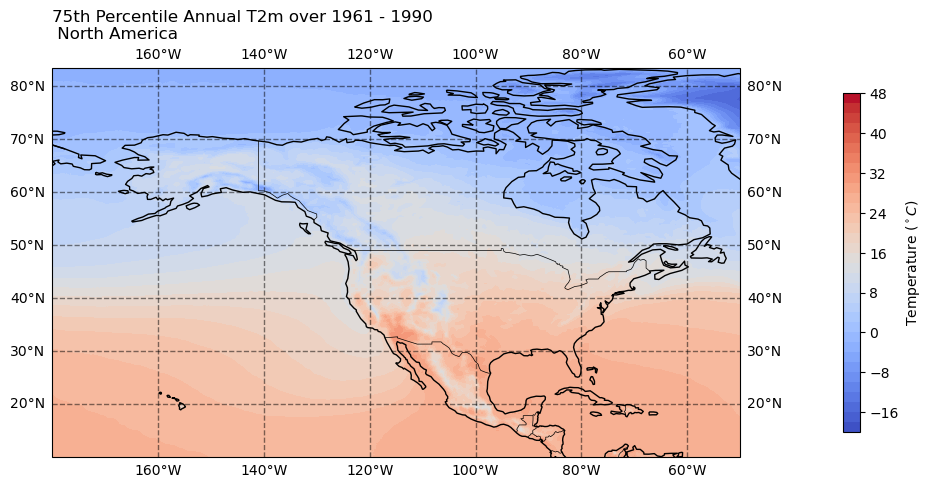

In [19]:
# make a north america map too

# try another way of plotting
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(1,1,1, projection=ccrs.PlateCarree())  
ax.set_title("75th Percentile Annual T2m over 1961 - 1990 \n North America", loc="left")
dataplot = ax.contourf(
    c_75.lon,
    c_75.lat,
    c_75-273.15,
    levels=np.arange(-20,50,2),
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.coolwarm,
)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
ax.set_extent((-180, -50, 10, 75))
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
fig.colorbar(dataplot, orientation="vertical", label="Temperature ($^\circ C$)",
             shrink=0.55, pad=0.11
            )